# 🔍 Notatbok 01 — Saksmappen

**Et helt gyldig krav ble avslått. Modellen sier nei. Hvorfor?**

Velkommen, detektiv. Et forsikringsselskap har satt i drift en maskinlæringsmodell
for å godkjenne eller avslå krav automatisk. Modellen har god samlet nøyaktighet,
men noe stemmer ikke.

**Kari** — en lojal kunde i 12 år med *null* tidligere krav — fikk nettopp
boligskadekravet sitt **avslått**. Ledelsen vil ha svar.

Ditt oppdrag: **finn ut hvorfor**.

### Oversikt over workshopen

| Notatbok | Tittel | Fokus |
|----------|--------|-------|
| **01** | Saksmappen | Last inn data, tren modell, møt mysteriet |
| **02** | Undersøk åstedet | Globale forklaringer (Perm. Importance, PDP, SHAP) |
| **03** | Avhør av mistenkte | Lokale forklaringer (SHAP waterfall, LIME, DiCE) |
| **04** | Når forklaringer lyver | Fallgruver — korrelasjon, lekkasje, ustabilitet |
| **05** | Skriv dommen | Interessentkommunikasjon og beslutningsmal |

## 0. Oppsett av miljø

In [1126]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn shap lime dice-ml ipywidgets

In [1127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Alle importer lastet inn.")

✅ Alle importer lastet inn.


## 1. Bli kjent med dataene

Vi har et datasett med historiske forsikringskrav. Hver rad er et krav med
egenskaper som beskriver kunden og selve kravet. Målvariabelen `approved`
forteller oss om kravet ble godkjent (1) eller avslått (0).

In [1128]:
import os
if IN_COLAB:
    from google.colab import files
    if not os.path.exists("claims.csv"):
        print("Vennligst last opp claims.csv")
        uploaded = files.upload()
    df = pd.read_csv("claims.csv")
else:
    df = pd.read_csv("../data/claims.csv")
print(f"Datasett: {df.shape[0]:,} krav × {df.shape[1]} egenskaper")
df.head(10)

Datasett: 5,000 krav × 17 egenskaper


,claimant_age,region,policy_type,years_as_customer,prior_claims,claim_amount,vehicle_value,sum_insured,police_report_filed,time_to_report_days,documentation_complete,witness_present,number_of_dependents,policy_premium_monthly,fraud_flag,_internal_score,approved
0,23,Oslo,auto,2,2,25793.99,160178.18,129102.78,0,9,1,1,2,249.90,0,100.0,1
1,65,Oslo,home,15,0,45612.63,238081.59,191600.72,1,18,1,0,2,315.33,0,65.6,1
2,58,Stavanger,travel,17,1,6896.28,336723.76,270391.88,1,7,1,0,1,618.01,0,91.9,1
3,45,Stavanger,travel,21,2,6564.36,178108.80,140033.23,0,7,1,0,2,329.43,0,79.9,1
4,44,Stavanger,auto,17,1,21112.88,192777.91,154219.49,0,8,1,0,2,270.03,0,89.6,1
5,71,Tromso,health,5,1,11428.62,179630.06,144506.48,0,3,1,1,2,196.22,0,63.3,1
6,23,Trondheim,travel,11,0,14598.87,262270.45,210314.02,0,5,1,0,3,445.15,0,100.0,1
7,28,Oslo,auto,2,2,175000.00,280000.00,224000.00,1,14,0,1,0,460.00,0,83.5,1
8,30,Stavanger,health,29,2,18110.78,293772.80,236333.63,0,8,1,1,2,584.86,0,53.8,1
9,23,Bergen,home,15,1,30660.42,75842.99,60727.22,0,18,1,0,1,191.54,0,100.0,1


In [1129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   claimant_age            5000 non-null   int64  
 1   region                  5000 non-null   str    
 2   policy_type             5000 non-null   str    
 3   years_as_customer       5000 non-null   int64  
 4   prior_claims            5000 non-null   int64  
 5   claim_amount            5000 non-null   float64
 6   vehicle_value           5000 non-null   float64
 7   sum_insured             5000 non-null   float64
 8   police_report_filed     5000 non-null   int64  
 9   time_to_report_days     5000 non-null   int64  
 10  documentation_complete  5000 non-null   int64  
 11  witness_present         5000 non-null   int64  
 12  number_of_dependents    5000 non-null   int64  
 13  policy_premium_monthly  5000 non-null   float64
 14  fraud_flag              5000 non-null   int64  
 15

In [1130]:
print("Fordeling av målvariabel:")
print(df["approved"].value_counts())
print(f"\nGodkjenningsrate: {df['approved'].mean():.1%}")

Fordeling av målvariabel:
approved
1    4194
0     806
Name: count, dtype: int64

Godkjenningsrate: 83.9%


### 📊 Rask utforskende analyse

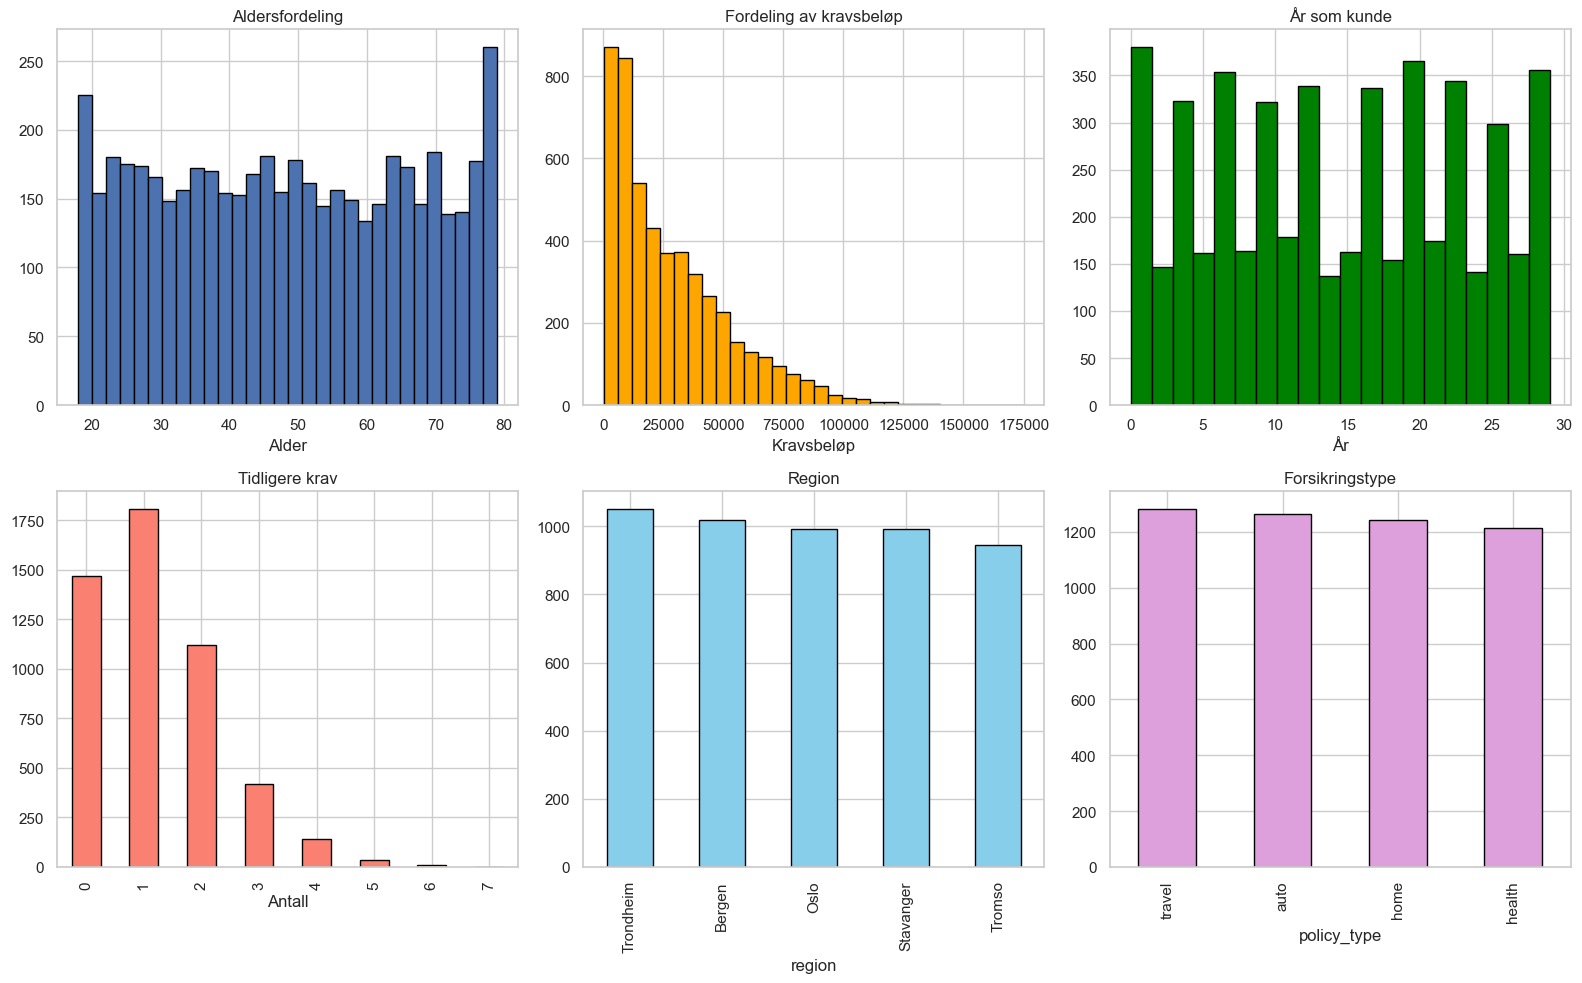

In [1131]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df["claimant_age"], bins=30, edgecolor="black")
axes[0, 0].set_title("Aldersfordeling")
axes[0, 0].set_xlabel("Alder")

axes[0, 1].hist(df["claim_amount"], bins=30, edgecolor="black", color="orange")
axes[0, 1].set_title("Fordeling av kravsbeløp")
axes[0, 1].set_xlabel("Kravsbeløp")

axes[0, 2].hist(df["years_as_customer"], bins=20, edgecolor="black", color="green")
axes[0, 2].set_title("År som kunde")
axes[0, 2].set_xlabel("År")

df["prior_claims"].value_counts().sort_index().plot.bar(ax=axes[1, 0], color="salmon", edgecolor="black")
axes[1, 0].set_title("Tidligere krav")
axes[1, 0].set_xlabel("Antall")

df["region"].value_counts().plot.bar(ax=axes[1, 1], color="skyblue", edgecolor="black")
axes[1, 1].set_title("Region")

df["policy_type"].value_counts().plot.bar(ax=axes[1, 2], color="plum", edgecolor="black")
axes[1, 2].set_title("Forsikringstype")

plt.tight_layout()
plt.show()

## 2. Tren svartboks-modellen

Vi trener en **XGBoost**-klassifiserer på **alle** tilgjengelige egenskaper.
Dette er vår «produksjonsmodell» — den svarte boksen vi må forklare.

In [1132]:
feature_cols = [c for c in df.columns if c != "approved"]
df_model = pd.get_dummies(df, columns=["region", "policy_type"], drop_first=True)
X = df_model.drop(columns=["approved"])
y = df_model["approved"]
feature_cols = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treningssett: {X_train.shape[0]:,}  |  Testsett: {X_test.shape[0]:,}")

Treningssett: 4,000  |  Testsett: 1,000


In [1133]:
model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric="logloss"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Avslått", "Godkjent"]))

              precision    recall  f1-score   support

     Avslått       0.74      0.68      0.71       161
    Godkjent       0.94      0.95      0.95       839

    accuracy                           0.91      1000
   macro avg       0.84      0.82      0.83      1000
weighted avg       0.91      0.91      0.91      1000



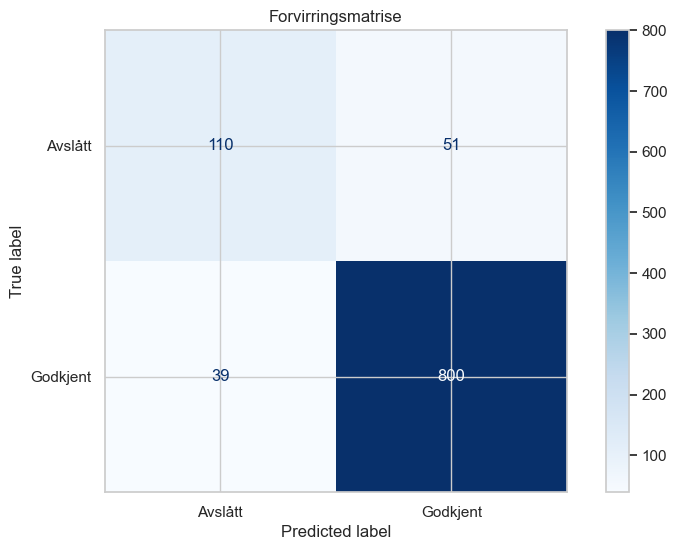

In [1134]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Avslått", "Godkjent"], cmap="Blues")
plt.title("Forvirringsmatrise")
plt.show()

## 3. Mysteriet — Karis avslåtte krav

Kari er rad **42** i datasettet vårt. La oss se på saksmappen hennes.

In [1135]:
kari = df.loc[42]
print("=" * 40)
print("  SAKSMAPPE: Kari (Rad 42)")
print("=" * 40)
for col in df.columns:
    print(f"  {col:.<25} {kari[col]}")
print("=" * 40)

  SAKSMAPPE: Kari (Rad 42)
  claimant_age............. 52
  region................... Trondheim
  policy_type.............. home
  years_as_customer........ 12
  prior_claims............. 0
  claim_amount............. 45000.0
  vehicle_value............ 310000.0
  sum_insured.............. 248000.0
  police_report_filed...... 0
  time_to_report_days...... 3
  documentation_complete... 1
  witness_present.......... 0
  number_of_dependents..... 2
  policy_premium_monthly... 520.0
  fraud_flag............... 0
  _internal_score.......... 22.4
  approved................. 0


In [1136]:
kari_X = X.loc[[42]]
pred = model.predict(kari_X)[0]
proba = model.predict_proba(kari_X)[0]
print(f"Modellens prediksjon: {'Godkjent' if pred == 1 else 'AVSLÅTT'}")
print(f"Sannsynlighet [Avslått, Godkjent]: [{proba[0]:.3f}, {proba[1]:.3f}]")

Modellens prediksjon: AVSLÅTT
Sannsynlighet [Avslått, Godkjent]: [0.925, 0.075]


### Noe stemmer ikke

Se på Karis profil:
- **12 år** som kunde — svært lojal
- **Null** tidligere krav — ingen misbrukshistorikk
- Rimelig kravsbeløp
- Ingen svindelflagg

Likevel sier modellen **AVSLÅTT** med høy sikkerhet.

Modellen er en svart boks. Den forteller oss ikke *hvorfor*. Det er akkurat
det resten av denne workshopen handler om: å bryte den opp.

## 4. Den andre mistenkte — Eriks godkjente krav

Mens Karis avslag er mystisk, er det en annen sak som fortjener oppmerksomhet.
Erik er rad **7** i datasettet.

In [1137]:
erik = df.loc[7]
print("=" * 40)
print("  SAKSMAPPE: Erik (Rad 7)")
print("=" * 40)
for col in df.columns:
    print(f"  {col:.<25} {erik[col]}")
print("=" * 40)

  SAKSMAPPE: Erik (Rad 7)
  claimant_age............. 28
  region................... Oslo
  policy_type.............. auto
  years_as_customer........ 2
  prior_claims............. 2
  claim_amount............. 175000.0
  vehicle_value............ 280000.0
  sum_insured.............. 224000.0
  police_report_filed...... 1
  time_to_report_days...... 14
  documentation_complete... 0
  witness_present.......... 1
  number_of_dependents..... 0
  policy_premium_monthly... 460.0
  fraud_flag............... 0
  _internal_score.......... 83.5
  approved................. 1


In [1138]:
erik_X = X.loc[[7]]
pred_e = model.predict(erik_X)[0]
proba_e = model.predict_proba(erik_X)[0]
print(f"Modellens prediksjon: {'Godkjent' if pred_e == 1 else 'AVSLÅTT'}")
print(f"Sannsynlighet [Avslått, Godkjent]: [{proba_e[0]:.3f}, {proba_e[1]:.3f}]")

Modellens prediksjon: Godkjent
Sannsynlighet [Avslått, Godkjent]: [0.000, 1.000]


### Noe stemmer ikke — igjen

Se på Eriks profil:
- **28 år** — ung kunde
- Bare **2 år** som kunde — kort historikk
- **To** tidligere krav
- **Høyt** kravsbeløp (75 000 NOK)

Likevel sier modellen **GODKJENT** med høy sikkerhet.

Kari — lojal, skadefri, beskjeden — ble avslått.
Erik — ung, kort historikk, høyt beløp — ble godkjent.

**To mysterier å løse.**

## 🏋️ Øvelse 1: Formuler din hypotese

Før vi bruker noen XAI-verktøy, skriv ned magefølelsen din.
Hvilke egenskaper tror du betyr mest? Hvorfor ble Kari avslått?

In [1139]:
# DIN HYPOTESE
# Viktigste egenskaper (min gjetning):
#   1. 
#   2. 
#   3. 
#
# Hvorfor Kari ble avslått (min gjetning):
#   
#
# Sikkerhet (1-5):

## 💾 Lagre artefakter for neste notatbøker

In [1140]:
import pickle

artifacts = {
    "model": model,
    "X_train": X_train, "X_test": X_test,
    "y_train": y_train, "y_test": y_test,
    "feature_cols": feature_cols,
    "df": df, "df_model": df_model, "X": X, "y": y,
}
save_path = "nb01_artifacts.pkl" if IN_COLAB else "../data/nb01_artifacts.pkl"
with open(save_path, "wb") as f:
    pickle.dump(artifacts, f)
print(f"✅ Artefakter lagret til {save_path}")

✅ Artefakter lagret til ../data/nb01_artifacts.pkl


## 🔑 Hovedpunkter

| Konsept | Detalj |
|---------|--------|
| Svartboks-modell | XGBoost — nøyaktig men ugjennomsiktig |
| Mysteriet | Kari (rad 42) avslått til tross for ren profil; Erik (rad 7) godkjent til tross for risikoprofil |
| Neste steg | Bruk globale forklaringer for å undersøke åstedet |

👉 **Neste:** [Notatbok 02 — Undersøk åstedet](02_global_explanations.ipynb)